## Домашнее задание №2 по НИС в 3 модуле: <br> Аналоговые фильтры

Рассматривается тип сигнала под номером 2:
$$ x_2(t) = \frac{a_2}{b_2 + |t-t_2|}exp(-c_2|t-t_3|)sinc(d_2t)$$

с параметрами: $$a_2 = -1, b_2 = 4, t_2 = -1, c_2 = 0.2, t_3 = 2, d_2 = 11 $$

Цель: проанализировать результаты пропуска сигналов через полосовые фильтры.

Задачи:
1) **Идеальный полосовой фильтр:** <br>
Выделить частоты, соответствующие ярко выраженным колебаниям сигнала, подобрать полосу частот, чтобы выделенные частоты лежали вне этой полосы, пропустить сигнал через идеальный полосовой фильтр с помощью прямого и обратного преобразования Фурье и передаточной функции фильтра, пропустить сигнал через идеальный полосовой фильтр с помощью свёртки сигнала с функцией отклика фильтра, сравнить результаты, дать комментарии сравнения.
2) **RC-цепочка, как полосовой фильтр:** <br>
Подобрать параметры цепочки так, чтобы полученный сигнал можно было рассматривать как аппроксимацию идеального полосового фильтра, пропустить сигнал через RC-цепочку с помощью прямого и обратного преобразования Фурье и передаточной функции цепочки, пропустить сигнал через RC-цепочку с помощью свёртки сигнала с функцией отклика RC-цепочки, сравнить результаты, дать комментарии сравнения.

Дедлайн: 23.03.2026 в 23:59

**Выполнил: Гайфиев Иван (23КНТ-6)**

### Некоторые важные параметры и функции из ДЗ-1

In [128]:
# необходимые фреймворки
import numpy as np
import matplotlib.pyplot as plt
import time

In [129]:
# ВХОДНЫЕ ДАННЫЕ
# задание параметров
a2 = -1.0 # сгладит спектр и повлияет на общую амплитуду
b2 = 4.0 # сгладит спектр и повлияет на общую амплитуду
t2 = -1.0 # влияет на фазу
c2 = 0.2 # чем больше, тем больше похоже на колокол нормального распределния
t3 = 2.0 # влияет на фазу
d2 = 11.0 # чем больше, тем шире прямоугольники

# Зафиксируем параметры:
tmin, tmax = -20, 20
N = 1000 # количество точек дискретизации по времени
M = 1000 # число точек дискретизации по частоте
lam_min = -10
lam_max = 10
# Обоснование выбора параметров:
# N и M подобраны так, чтобы частота дискретизации была выше минимальной необходимой,
# чтобы вычислить сигнал без помех, согласно теореме Шеннона-Котельникова.
# tmin, tmax, lam_min, lam_max подобраны по принципу симметричности интервалов относительно
# t = 0 и lam = 0

t = np.linspace(tmin, tmax, N)
lambdas = np.linspace(lam_min, lam_max, M)

# задание функции
x_func = lambda t: (a2 / (b2 + np.abs(t - t2))) * np.exp(-c2 * np.abs(t - t3)) * np.sinc(d2 * t)

In [130]:
def plot_signal(func, tmin=-10, tmax=10, N=1000, figsize=(10, 4), title="График сгенерированного сигнала во времени"):
  t = np.linspace(tmin, tmax, N)
  x=func(t)
  plt.figure(figsize=figsize)
  plt.plot(t, x, color='blue', linewidth=1.5, label='Сигнал $x_2(t)$')
  plt.title(title)
  plt.xlabel('Время $t$, с')
  plt.ylabel('Амплитуда $x(t)$')
  plt.axhline(0, color='black', linewidth=0.5)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.legend()
  plt.tight_layout()
  plt.show()


In [131]:
def forward_FT(func, tmin, tmax, N, M, lam_min, lam_max):
    tm = time.time()
    t = np.linspace(tmin, tmax, N)
    a = (tmax - tmin)/(N)
    x = func(t)
    lambdas = np.linspace(lam_min, lam_max, M)
    X = np.zeros(M, dtype=complex)
    for k in range(M):
         X[k] = a * np.sum(x * np.exp(-2 * np.pi * 1j * t * lambdas[k]))
    print(time.time() - tm, 'сек.')
    return lambdas, X

In [132]:
def fast_FT(func, tmin, tmax, N):
    tm = time.time()
    t = np.linspace(tmin, tmax, N)
    a = (tmax - tmin)/(N)
    x = func(t)
    X = np.fft.fft(x) * a
    freqs = np.fft.fftfreq(N, a)
    print(time.time() - tm, 'сек.')
    return freqs, X  # перевод в λ

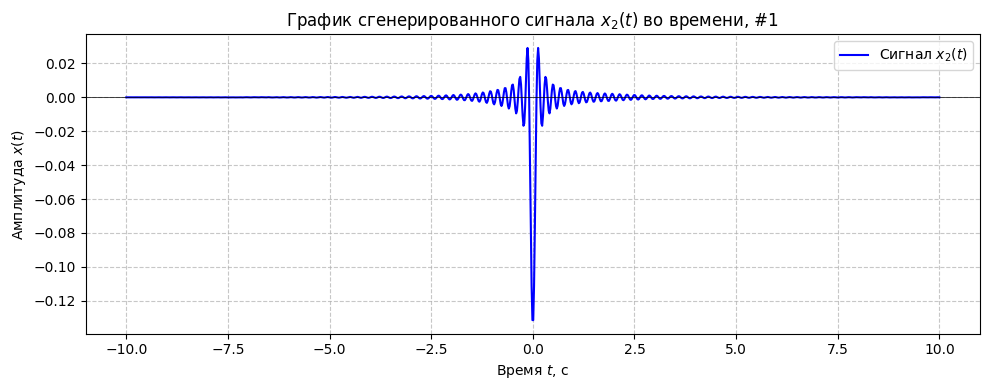

In [123]:
# Напоминание о том, как выглядит исходный сигнал
plot_signal(x_func, title="График сгенерированного сигнала $x_2(t)$ во времени, #1")

0.21069073677062988 сек.


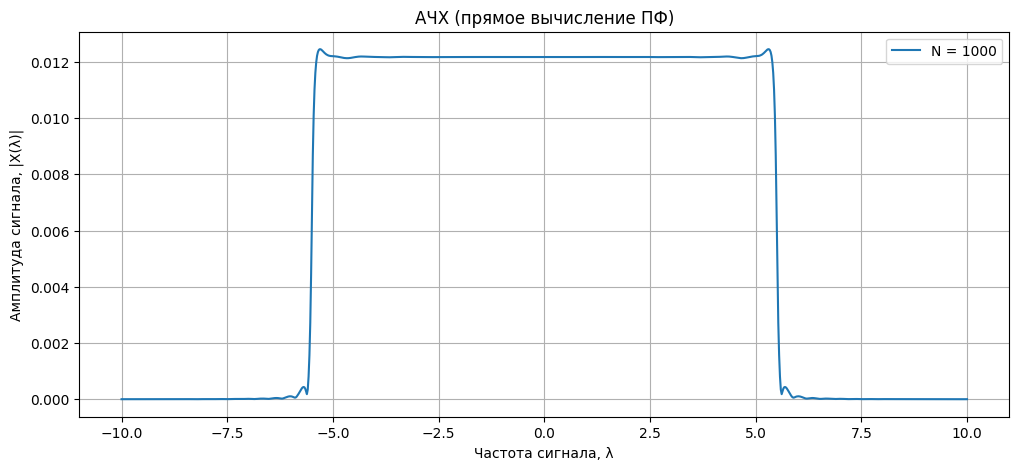

In [126]:
# И напоминание как выглядит спектр сигнала после БПФ

lam, X = forward_FT(x_func, tmin, tmax, N, M, lam_min, lam_max)

plt.figure(figsize=(12,5))
plt.plot(lam, np.abs(X), label=f"N = {N}")
plt.title("АЧХ (прямое вычисление ПФ)")
plt.xlabel("Частота сигнала, λ")
plt.ylabel("Амплитуда сигнала, |X(λ)|")
plt.grid()
plt.legend()
plt.show()

### 1. Идеальный полосовой фильтр

1) На основе спектрального анализа можно сделать вывод, что частоты примерно от -5.5 до 5.5 соответствуют ярко выраженным колебаниям сигнала.
2) Составляющая d2 в функции sinc соответствуют этим частотам, так как ширина интервала частот напрямую зависит от значения d2
3) Полоса частот, вне которой лежат выделенные частоты (возьмём к примеру): [ -3, 3 ]

#### Реализация алгоритма пропуска сигнала через идеальный полосовой фильтр с помощью передаточной функции

Формула применения передаточной функции к ПФ входного сигнала для данного фильтра:
$$ \hat{y} = H(λ) \hat{x}(λ) =
\begin{cases}
\hat{x}(λ), λ_{min} < λ < λ_{max} \\
0, else
\end{cases}$$

Для перехода к выходному сигналу фильтра применяется Обратное ПФ:
$$ y(t) = IFT(\hat{y})$$

Функция Обратного ПФ (по определению):
$$x(t) = IFT(\hat{x}) = \int_{-∞}^{∞} \hat{x}(λ) \exp^{2 \pi i λ t} dλ$$

In [136]:
# Реализация механизма работы идеального фильра

# Идея:
# 1) у нас есть входной сигнал, мы получаем значения БПФ и сетку частот (X, freqs), применяя функцию
# 2) создаём маску, которая обнуляет частоты меньше lowcut и больше highcut. Применяем маску к значениям freqs, создаём передаточную функцию
# 3) Применяем передаточную функцию к массиву значений БПФ, получаем отфильтрованные (\hat{y})
# 4) Подаём отфильтрованные частоты в функцию ОПФ, получаем выходной сигнал фильтра - значения сигнала в зависимости от времени.

def ideal_bandpass_filter(func, tmin, tmax, N, lowcut, highcut):
    freqs, X = fast_FT(func, tmin, tmax, N) # прямой БПФ
    H = np.where((freqs >= lowcut) & (freqs <= highcut), 1, 0) # передаточная функция в виде маски
    X_filtered = X * H # применение маски
    filtered_signal = np.fft.irfft(X_filtered, n=N)  # обратное ПФ

    return freqs, X_filtered, filtered_signal

# протестируем: пропустим через фильтр исходный сигнал, вырезая из него частоты вне интервала [-3, 3]
freqs, X_filtered, filtered_signal = ideal_bandpass_filter(x_func, tmin, tmax, N, -3, 3)

0.001127004623413086 сек.


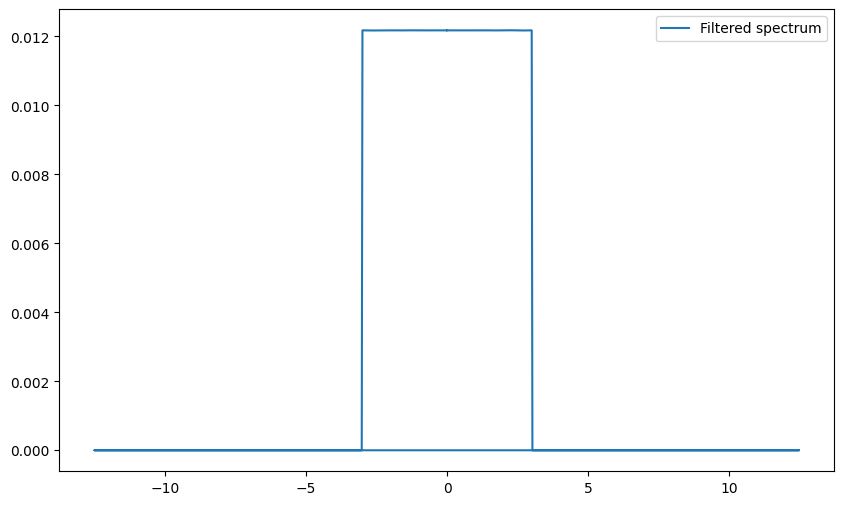

In [140]:
# Визуализация отфильтрованного спектра частот
plt.figure(figsize=(10, 6))
plt.plot(freqs, np.abs(X_filtered), label='Filtered spectrum') # применяем np.abs, чтобы избавиться от комплексности: |z| = sqrt(a^2 + b^2)
plt.legend()
plt.show()

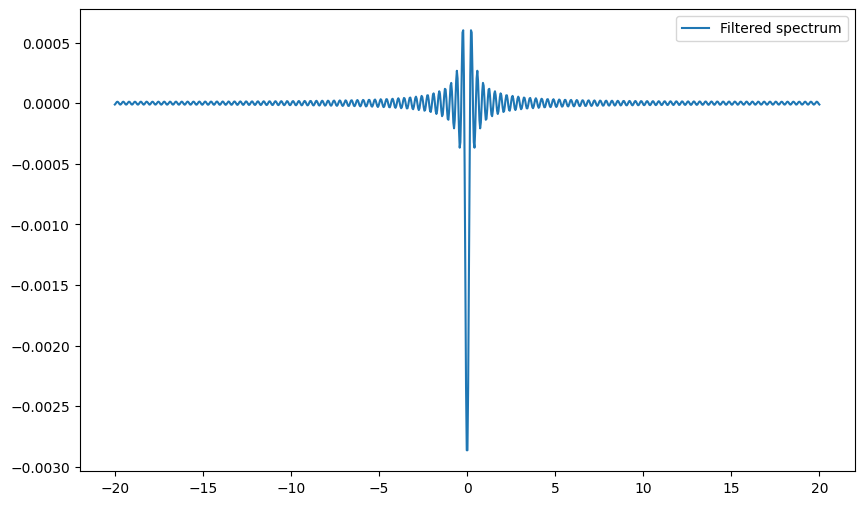

In [150]:
# Визуализация отфильтрованного выходного сигнала
plt.figure(figsize=(10, 6))
plt.plot(t, filtered_signal, label='Filtered spectrum')
plt.legend()
plt.show()

#### Сравнение результатов фильтрации с исходным сигналом (передаточная функция)

Исходный сигнал является затухающим на интервалах (−∞,+∞). Его спектр содержит частоты преимущественно в диапазоне [−5.5,5.5], при этом амплитуда спектра в этом диапазоне остаётся практически постоянной. Вне данного диапазона амплитуда быстро уменьшается, однако наблюдаются небольшие осцилляции, обусловленные дискретизацией сигнала и конечной длиной выборки.

Применение идеального полосового фильтра на основе передаточной функции с использованием прямого и обратного преобразования Фурье существенно изменяет как спектр сигнала, так и его временное представление. В рамках фильтрации были сохранены только частоты в диапазоне [−3,3], в то время как остальные компоненты спектра были обнулены.

Удаление высокочастотных составляющих привело к сглаживанию сигнала во временной области. При этом сигнал утратил часть своей локализованности и стал более протяжённым. Кроме того, вследствие резкого обрезания спектра наблюдаются осцилляции во временной области (эффект “звонка”), что является характерной особенностью идеальных фильтров.

Таким образом, применение полосового фильтра демонстрирует взаимосвязь между шириной спектра сигнала и его временной формой: чем уже спектр, тем более растянутым и осциллирующим становится сигнал во времени.



#### Реализация алгоритма пропуска сигнала через идеальный полосовой фильтр с помощью свёртки

Ваш текст

In [ ]:
# code with function, comments and visualization

#### Сравнение результатов фильтрации с исходным сигналом (свёртка)

Ваш текст


#### Комментарий к сравнению двух способов получения отфильтрованного сигнала

Ваш текст

### 2. RC-цепочка, как полосовой фильтр

Оформление аналогично структуре пункта 1 (Идеальный полосовой фильтр)